In [1]:
import pandas as pd

df = pd.read_csv('train_transaction.csv')

print("Shape:", df.shape)
print("Fraud rate in sample:", df['isFraud'].mean().round(4))
print("\nColumns (first 30):", list(df.columns[:30]))
print("\nTotal columns:", len(df.columns))
print("\nDtypes summary:\n", df.dtypes.value_counts())
print("\nTransactionAmt stats:\n", df['TransactionAmt'].describe())

Shape: (590540, 394)
Fraud rate in sample: 0.035

Columns (first 30): ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13']

Total columns: 394

Dtypes summary:
 float64    376
object      14
int64        4
Name: count, dtype: int64

TransactionAmt stats:
 count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


In [2]:
trans = pd.read_csv('train_transaction.csv')
ident = pd.read_csv('train_identity.csv')

# left join: keep all transactions, attach identity where it exists
df = trans.merge(ident, on='TransactionID', how='left')
print("Merged shape:", df.shape)

# how much identity coverage do we actually have?
has_identity = df['DeviceType'].notna()
print(f"\n% of transactions with identity/device data: {has_identity.mean()*100:.1f}%")

# does having identity data correlate with fraud?
print("\nFraud rate WITH identity data:", df[has_identity]['isFraud'].mean().round(4))
print("Fraud rate WITHOUT identity data:", df[~has_identity]['isFraud'].mean().round(4))

df.to_csv('merged.csv', index=False)
print("\nSaved merged.csv")

Merged shape: (590540, 434)

% of transactions with identity/device data: 23.8%

Fraud rate WITH identity data: 0.0796
Fraud rate WITHOUT identity data: 0.021

Saved merged.csv


In [3]:
# Does ProductCD explain the identity/fraud relationship, or is it independent?
identity_by_product = df.groupby('ProductCD').agg(
    fraud_rate=('isFraud', 'mean'),
    has_identity_rate=('DeviceType', lambda x: x.notna().mean()),
    n=('isFraud', 'count')
).round(3)
print("By ProductCD:\n", identity_by_product)

# Within each ProductCD, does having identity data still predict fraud?
print("\nFraud rate WITH vs WITHOUT identity, split by ProductCD:")
for product in df['ProductCD'].unique():
    subset = df[df['ProductCD'] == product]
    has_id = subset['DeviceType'].notna()
    if has_id.sum() > 0 and (~has_id).sum() > 0:
        print(f"{product}: with_identity={subset[has_id]['isFraud'].mean():.3f}, "
              f"without_identity={subset[~has_id]['isFraud'].mean():.3f}, n={len(subset)}")

By ProductCD:
            fraud_rate  has_identity_rate       n
ProductCD                                       
C               0.117              0.890   68519
H               0.048              0.972   33024
R               0.038              0.966   37699
S               0.059              0.969   11628
W               0.020              0.000  439670

Fraud rate WITH vs WITHOUT identity, split by ProductCD:
H: with_identity=0.049, without_identity=0.012, n=33024
C: with_identity=0.124, without_identity=0.055, n=68519
S: with_identity=0.058, without_identity=0.103, n=11628
R: with_identity=0.039, without_identity=0.017, n=37699


In [4]:
df.shape
df['isFraud'].mean()

np.float64(0.03499000914417313)

In [5]:
df.shape

(590540, 434)

In [6]:
import numpy as np

print("TransactionAmt — Legit:\n", df[df['isFraud']==0]['TransactionAmt'].describe())
print("\nTransactionAmt — Fraud:\n", df[df['isFraud']==1]['TransactionAmt'].describe())

# log-transform since amount is heavily right-skewed
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
print("\nLog-amount — Legit mean:", df[df['isFraud']==0]['TransactionAmt_log'].mean().round(3))
print("Log-amount — Fraud mean:", df[df['isFraud']==1]['TransactionAmt_log'].mean().round(3))

TransactionAmt — Legit:
 count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

TransactionAmt — Fraud:
 count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64

Log-amount — Legit mean: 4.383
Log-amount — Fraud mean: 4.374


Feed TransactionAmt_log rather than raw TransactionAmt — it's the more honest representation, and confirms amount alone won't carry much predictive weight.

In [7]:
card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

for col in card_cols:
    print(f"{col}: unique={df[col].nunique()}, missing={df[col].isna().mean()*100:.2f}%, dtype={df[col].dtype}")

print("\ncard4 (network) value counts:\n", df['card4'].value_counts(dropna=False))
print("\ncard6 (type) value counts:\n", df['card6'].value_counts(dropna=False))

card1: unique=13553, missing=0.00%, dtype=int64
card2: unique=500, missing=1.51%, dtype=float64
card3: unique=114, missing=0.27%, dtype=float64
card4: unique=4, missing=0.27%, dtype=object
card5: unique=119, missing=0.72%, dtype=float64
card6: unique=4, missing=0.27%, dtype=object

card4 (network) value counts:
 card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64

card6 (type) value counts:
 card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64


In [8]:
c_cols = [f'C{i}' for i in range(1, 15)]
d_cols = [f'D{i}' for i in range(1, 16)]

print("=== C columns: missingness + correlation with isFraud ===")
for col in c_cols:
    missing = df[col].isna().mean() * 100
    corr = df[col].corr(df['isFraud'])
    print(f"{col}: missing={missing:.2f}%, corr_with_fraud={corr:.4f}")

print("\n=== D columns: missingness + correlation with isFraud ===")
for col in d_cols:
    missing = df[col].isna().mean() * 100
    corr = df[col].corr(df['isFraud'])
    print(f"{col}: missing={missing:.2f}%, corr_with_fraud={corr:.4f}")

=== C columns: missingness + correlation with isFraud ===
C1: missing=0.00%, corr_with_fraud=0.0306
C2: missing=0.00%, corr_with_fraud=0.0372
C3: missing=0.00%, corr_with_fraud=-0.0068
C4: missing=0.00%, corr_with_fraud=0.0304
C5: missing=0.00%, corr_with_fraud=-0.0308
C6: missing=0.00%, corr_with_fraud=0.0209
C7: missing=0.00%, corr_with_fraud=0.0282
C8: missing=0.00%, corr_with_fraud=0.0321
C9: missing=0.00%, corr_with_fraud=-0.0317
C10: missing=0.00%, corr_with_fraud=0.0284
C11: missing=0.00%, corr_with_fraud=0.0275
C12: missing=0.00%, corr_with_fraud=0.0319
C13: missing=0.00%, corr_with_fraud=-0.0111
C14: missing=0.00%, corr_with_fraud=0.0079

=== D columns: missingness + correlation with isFraud ===
D1: missing=0.21%, corr_with_fraud=-0.0672
D2: missing=47.55%, corr_with_fraud=-0.0836
D3: missing=44.51%, corr_with_fraud=-0.0463
D4: missing=28.60%, corr_with_fraud=-0.0672
D5: missing=52.47%, corr_with_fraud=-0.0646
D6: missing=87.61%, corr_with_fraud=-0.0572
D7: missing=93.41%, cor

In [9]:
m_cols = [f'M{i}' for i in range(1, 10)]

for col in m_cols:
    print(f"\n=== {col} ===")
    print(f"Missing: {df[col].isna().mean()*100:.2f}%")
    # fraud rate broken down by each category of the flag (T, F, NaN)
    print(df.groupby(col, dropna=False)['isFraud'].agg(['mean', 'count']).round(4))


=== M1 ===
Missing: 45.91%


       mean   count
M1                 
F    0.0000      25
T    0.0199  319415
NaN  0.0528  271100

=== M2 ===
Missing: 45.91%
       mean   count
M2                 
F    0.0349   33972
T    0.0181  285468
NaN  0.0528  271100

=== M3 ===
Missing: 45.91%
       mean   count
M3                 
F    0.0303   67709
T    0.0171  251731
NaN  0.0528  271100

=== M4 ===
Missing: 47.66%
       mean   count
M4                 
M0   0.0366  196405
M1   0.0271   52826
M2   0.1137   59865
NaN  0.0186  281444

=== M5 ===
Missing: 59.35%
       mean   count
M5                 
F    0.0265  132491
T    0.0377  107567
NaN  0.0374  350482

=== M6 ===
Missing: 28.68%
       mean   count
M6                 
F    0.0237  227856
T    0.0170  193324
NaN  0.0707  169360

=== M7 ===
Missing: 58.64%
       mean   count
M7                 
F    0.0193  211374
T    0.0221   32901
NaN  0.0458  346265

=== M8 ===
Missing: 58.63%
       mean   count
M8                 
F    0.0217  155251
T    0.0162   89037
NaN 

In [10]:
import networkx as nx

# Drop rows missing either key (small %, and we can't build edges without both)
graph_df = df.dropna(subset=['card1', 'addr1'])[['card1', 'addr1']].copy()

# Prefix values so card1=1000 and addr1=1000 don't collide as the same node
graph_df['card_node'] = 'card_' + graph_df['card1'].astype(int).astype(str)
graph_df['addr_node'] = 'addr_' + graph_df['addr1'].astype(int).astype(str)

# De-duplicate: we only need ONE edge per unique (card, addr) pair,
# not one edge per transaction — otherwise heavy-traffic legit cards
# would dominate purely from transaction volume, not network structure
edges = graph_df[['card_node', 'addr_node']].drop_duplicates()
print("Unique card-address edges:", len(edges))
print("Unique cards:", graph_df['card_node'].nunique())
print("Unique addresses:", graph_df['addr_node'].nunique())

# Build the bipartite graph
G = nx.Graph()
G.add_edges_from(edges.itertuples(index=False, name=None))

print("\nTotal nodes:", G.number_of_nodes())
print("Total edges:", G.number_of_edges())

Unique card-address edges: 37531
Unique cards: 12066
Unique addresses: 332

Total nodes: 12398
Total edges: 37531


In [11]:
# Degree for card nodes only
card_degree = {n: d for n, d in G.degree() if n.startswith('card_')}

# Map back onto the original dataframe
df['card_node'] = 'card_' + df['card1'].astype(int).astype(str)
df['card1_addr_degree'] = df['card_node'].map(card_degree)

print("card1_addr_degree — Legit:\n", df[df['isFraud']==0]['card1_addr_degree'].describe())
print("\ncard1_addr_degree — Fraud:\n", df[df['isFraud']==1]['card1_addr_degree'].describe())

card1_addr_degree — Legit:
 count    564635.000000
mean         26.412447
std          19.626754
min           1.000000
25%           7.000000
50%          25.000000
75%          44.000000
max          64.000000
Name: card1_addr_degree, dtype: float64

card1_addr_degree — Fraud:
 count    20390.000000
mean        25.235998
std         18.772645
min          1.000000
25%          9.000000
50%         21.000000
75%         40.000000
max         64.000000
Name: card1_addr_degree, dtype: float64


In [12]:
graph_df2 = df.dropna(subset=['card1', 'DeviceInfo'])[['card1', 'DeviceInfo']].copy()
graph_df2['card_node'] = 'card_' + graph_df2['card1'].astype(int).astype(str)
graph_df2['device_node'] = 'device_' + graph_df2['DeviceInfo'].astype(str)

edges2 = graph_df2[['card_node', 'device_node']].drop_duplicates()
print("Unique card-device edges:", len(edges2))
print("Unique cards:", graph_df2['card_node'].nunique())
print("Unique devices:", graph_df2['device_node'].nunique())

G2 = nx.Graph()
G2.add_edges_from(edges2.itertuples(index=False, name=None))
print("\nTotal nodes:", G2.number_of_nodes())
print("Total edges:", G2.number_of_edges())

Unique card-device edges: 26141
Unique cards: 7853
Unique devices: 1786

Total nodes: 9639
Total edges: 26141


In [13]:
# Map device-degree back onto the dataframe
device_degree = {n: d for n, d in G2.degree() if n.startswith('card_')}
df['card_device_degree'] = df['card_node'].map(device_degree)

# Collapse to ONE row per card, so high-transaction-volume cards
# don't get counted repeatedly and bias the comparison
card_level = df.dropna(subset=['card_device_degree']).groupby('card1').agg(
    device_degree=('card_device_degree', 'first'),
    fraud_rate=('isFraud', 'mean'),          # % of THIS card's transactions that are fraud
    n_transactions=('isFraud', 'count')       # how active this card is
)

print("Correlation: device_degree vs per-card fraud_rate:", 
      card_level['device_degree'].corr(card_level['fraud_rate']).round(4))

print("\nAvg fraud_rate by device_degree bucket:")
card_level['degree_bucket'] = pd.cut(card_level['device_degree'], 
                                       bins=[0,1,2,3,5,10,100], 
                                       labels=['1','2','3','4-5','6-10','10+'])
print(card_level.groupby('degree_bucket', observed=True).agg(
    avg_fraud_rate=('fraud_rate','mean'),
    n_cards=('fraud_rate','count')
).round(4))

Correlation: device_degree vs per-card fraud_rate: 0.0345

Avg fraud_rate by device_degree bucket:
               avg_fraud_rate  n_cards
degree_bucket                         
1                      0.0455     4061
2                      0.0399     1512
3                      0.0265      878
4-5                    0.0374      737
6-10                   0.0431      419
10+                    0.0823      225


In [14]:
df['high_device_degree'] = (df['card_device_degree'] >= 10).astype(int)
print(df.groupby('high_device_degree')['isFraud'].agg(['mean', 'count']))

                        mean   count
high_device_degree                  
0                   0.021534  288470
1                   0.047840  302070


In [15]:
# Same graph (G2), but now look at degree from the DEVICE side instead of the card side
device_degree_rev = {n: d for n, d in G2.degree() if n.startswith('device_')}

df['device_node'] = 'device_' + df['DeviceInfo'].astype(str)
df['device_card_degree'] = df['device_node'].map(device_degree_rev)

# Collapse to one row per device, same logic as before —
# avoid high-transaction-volume devices skewing the comparison
device_level = df.dropna(subset=['device_card_degree']).groupby('DeviceInfo').agg(
    card_degree=('device_card_degree', 'first'),
    fraud_rate=('isFraud', 'mean'),
    n_transactions=('isFraud', 'count')
)

print("Correlation: device's card_degree vs per-device fraud_rate:",
      device_level['card_degree'].corr(device_level['fraud_rate']).round(4))

print("\nAvg fraud_rate by card_degree bucket:")
device_level['degree_bucket'] = pd.cut(device_level['card_degree'],
                                         bins=[0,1,2,3,5,10,20,1000],
                                         labels=['1','2','3','4-5','6-10','11-20','20+'])
print(device_level.groupby('degree_bucket', observed=True).agg(
    avg_fraud_rate=('fraud_rate','mean'),
    n_devices=('fraud_rate','count')
).round(4))

Correlation: device's card_degree vs per-device fraud_rate: -0.0009

Avg fraud_rate by card_degree bucket:
               avg_fraud_rate  n_devices
degree_bucket                           
1                      0.0407        549
2                      0.0677        257
3                      0.0676        182
4-5                    0.1020        238
6-10                   0.1190        233
11-20                  0.1541        174
20+                    0.1251        149


In [16]:
generic_devices = ['Windows', 'iOS Device', 'MacOS', 'Trident/7.0', 'rv:11.0', 'rv:57.0']

specific_device_level = device_level[~device_level.index.isin(generic_devices)]

print("Correlation (specific devices only):", 
      specific_device_level['card_degree'].corr(specific_device_level['fraud_rate']).round(4))

print("\nAvg fraud_rate by card_degree bucket (specific devices only):")
print(specific_device_level.groupby('degree_bucket', observed=True).agg(
    avg_fraud_rate=('fraud_rate','mean'),
    n_devices=('fraud_rate','count')
).round(4))

Correlation (specific devices only): 0.0731

Avg fraud_rate by card_degree bucket (specific devices only):
               avg_fraud_rate  n_devices
degree_bucket                           
1                      0.0407        549
2                      0.0677        257
3                      0.0676        182
4-5                    0.1020        238
6-10                   0.1190        233
11-20                  0.1541        174
20+                    0.1258        147


In [17]:
top_devices = specific_device_level[specific_device_level['degree_bucket'] == '20+'].sort_values('card_degree', ascending=False)
print(top_devices.head(20))

                               card_degree  fraud_rate  n_transactions  \
DeviceInfo                                                               
SM-G930V Build/NRD90M                167.0    0.000000             274   
SM-G950U Build/NRD90M                164.0    0.055172             290   
SM-G955U Build/NRD90M                163.0    0.100610             328   
rv:59.0                              157.0    0.121547             362   
SAMSUNG                              157.0    0.021277             235   
rv:58.0                              146.0    0.182156             269   
rv:52.0                              140.0    0.046875             256   
SM-N950U Build/NMF26X                133.0    0.062201             209   
rv:48.0                              102.0    0.011236             178   
SM-G935V Build/NRD90M                 91.0    0.000000             137   
SM-G935F Build/NRD90M                 80.0    0.092814             334   
SM-G950F Build/NRD90M                 

In [18]:
feature_cols = (
    ['TransactionAmt_log', 'card1', 'card2', 'card3', 'card5'] +
    [f'C{i}' for i in range(1, 15)] +
    [f'D{i}' for i in range(1, 16)] +
    ['high_device_degree']
)

categorical_cols = ['card4', 'card6'] + [f'M{i}' for i in range(1, 10)]

model_df = df[feature_cols + categorical_cols + ['isFraud', 'TransactionDT']].copy()

# Encode categoricals as XGBoost-friendly category dtype 
# (lets XGBoost handle missing values and splits natively, no manual one-hot needed)
for col in categorical_cols:
    model_df[col] = model_df[col].astype('category')

# Chronological split: earliest 70% for train, latest 30% for test
model_df = model_df.sort_values('TransactionDT')
split_idx = int(len(model_df) * 0.7)

train = model_df.iloc[:split_idx]
test = model_df.iloc[split_idx:]

X_train = train[feature_cols + categorical_cols]
y_train = train['isFraud']
X_test = test[feature_cols + categorical_cols]
y_test = test['isFraud']

print("Train shape:", X_train.shape, "Fraud rate:", y_train.mean().round(4))
print("Test shape:", X_test.shape, "Fraud rate:", y_test.mean().round(4))
print("\nTrain time range:", train['TransactionDT'].min(), "-", train['TransactionDT'].max())
print("Test time range:", test['TransactionDT'].min(), "-", test['TransactionDT'].max())

Train shape: (413378, 46) Fraud rate: 0.0352
Test shape: (177162, 46) Fraud rate: 0.0346

Train time range: 86400 - 10437996
Test time range: 10438003 - 15811131


In [19]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, classification_report

# scale_pos_weight = ratio of negative to positive class,
# tells XGBoost to weight fraud cases more heavily during training
# so it doesn't just learn to always predict "not fraud"
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,      # lets XGBoost use the category dtype columns directly
    tree_method='hist',           # faster histogram-based training
    eval_metric='aucpr',          # area under precision-recall curve — better than plain AUC for imbalanced data
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# Predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

scale_pos_weight: 27.43
[0]	validation_0-aucpr:0.30739
[50]	validation_0-aucpr:0.44550
[100]	validation_0-aucpr:0.46221
[150]	validation_0-aucpr:0.46741
[200]	validation_0-aucpr:0.47125
[250]	validation_0-aucpr:0.47324
[299]	validation_0-aucpr:0.47572

ROC-AUC: 0.8976
PR-AUC: 0.4907


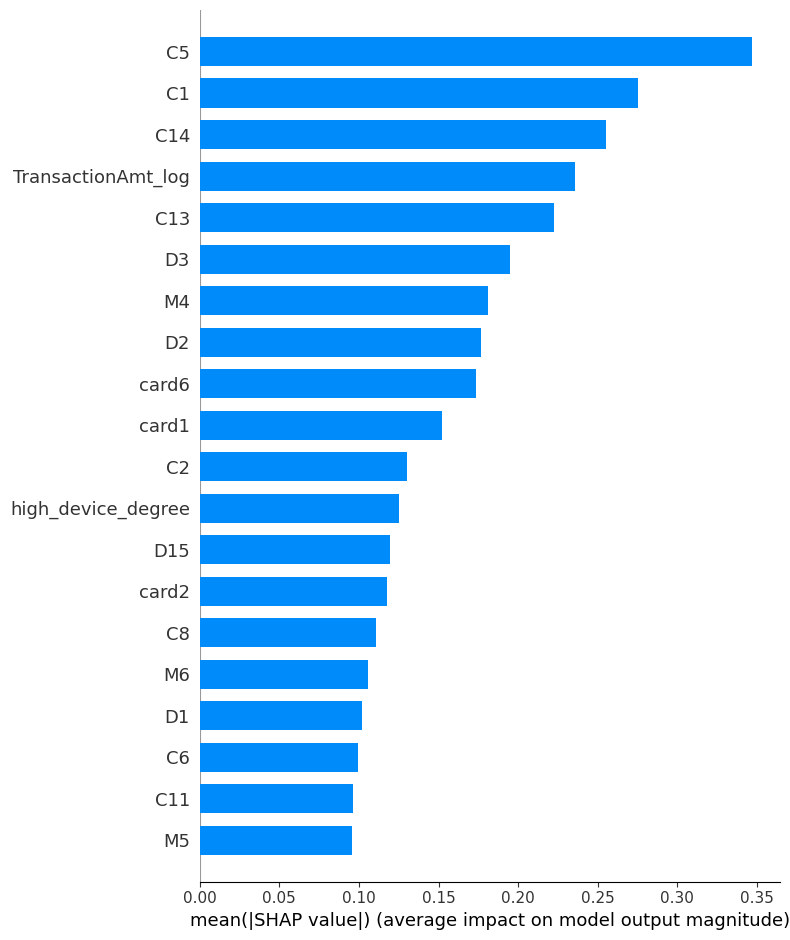

In [20]:
import shap

# TreeExplainer is the fast, exact method for tree-based models like XGBoost
explainer = shap.TreeExplainer(model)

# Compute SHAP values on a sample of the test set (full test set works too,
# but sampling keeps this fast while you're iterating — bump this up later if you want)
sample = X_test.sample(n=5000, random_state=42)
shap_values = explainer.shap_values(sample)

# Global importance — mean absolute SHAP value per feature, ranked
shap.summary_plot(shap_values, sample, plot_type='bar', show=True)

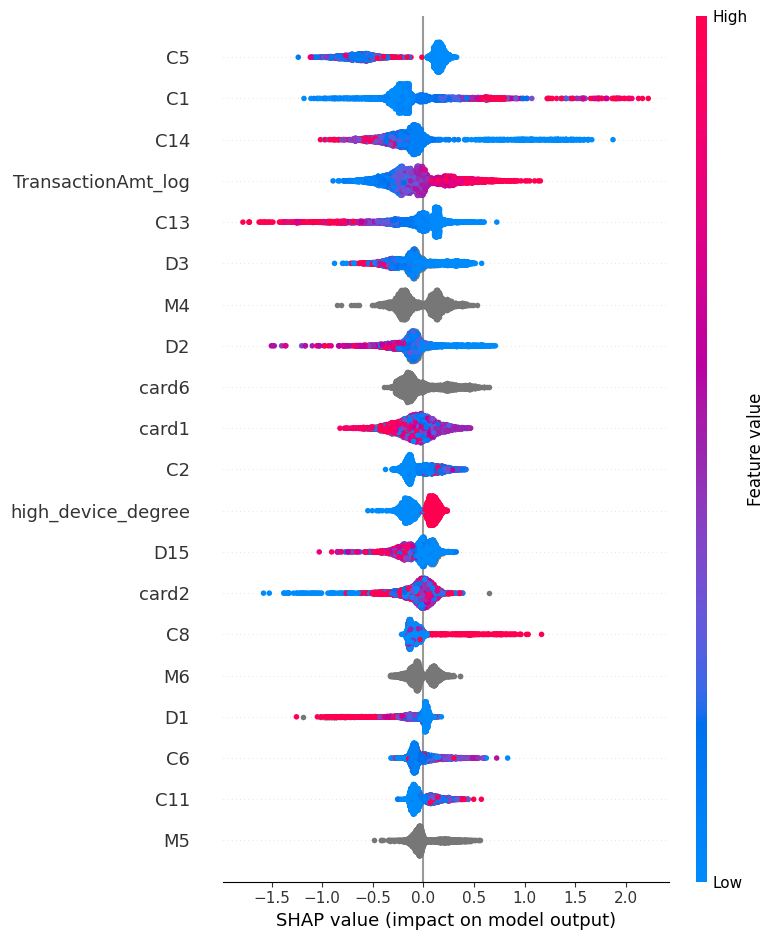

In [21]:
# The richer view: shows direction (does high/low value push toward fraud?)
# alongside magnitude — this is the one worth screenshotting for your README/resume
shap.summary_plot(shap_values, sample, show=True)

In [22]:
v_cols = [f'V{i}' for i in range(1, 340)]

# Missingness across the V-block
v_missing = df[v_cols].isna().mean().sort_values(ascending=False)
print("V-column missingness — distribution:")
print(v_missing.describe())
print("\nHow many V-columns are >50% missing:", (v_missing > 0.5).sum())
print("How many V-columns are >90% missing:", (v_missing > 0.9).sum())

# Redundancy check — are these columns highly correlated with each other?
# (sample a subset since 339x339 correlation is expensive)
v_sample = df[v_cols].sample(n=50000, random_state=42)
corr_matrix = v_sample.corr().abs()

# For each column, find its single highest correlation with another V-column
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (upper > 0.95).sum().sum()
print(f"\nNumber of V-column pairs with >0.95 correlation: {high_corr_pairs}")

V-column missingness — distribution:
count    339.000000
mean       0.430385
std        0.358801
min        0.000020
25%        0.002149
50%        0.472935
75%        0.779134
max        0.861237
dtype: float64

How many V-columns are >50% missing: 159
How many V-columns are >90% missing: 0

Number of V-column pairs with >0.95 correlation: 634


In [23]:
# Check which V-columns became constant (or near-constant) after median-fill
v_sample_filled = v_sample.fillna(v_sample.median())
variances = v_sample_filled.var()
zero_var_cols = variances[variances == 0].index.tolist()
print(f"Zero-variance columns after fillna: {len(zero_var_cols)}")
print(zero_var_cols)

# Drop those before computing correlation — a constant column has no
# meaningful correlation with anything, and can't help the model anyway
v_cols_clean = [c for c in v_cols if c not in zero_var_cols]
v_sample_filled_clean = v_sample_filled[v_cols_clean]

corr = v_sample_filled_clean.corr().abs()

# Double-check: any remaining NaNs in the correlation matrix at all?
print("\nNaNs remaining in correlation matrix:", corr.isna().sum().sum())

Zero-variance columns after fillna: 1
['V305']

NaNs remaining in correlation matrix: 0


In [24]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# Convert correlation to distance for clustering (1 - corr = distance)
distance_matrix = 1 - corr
np.fill_diagonal(distance_matrix.values, 0)
condensed = squareform(distance_matrix.values, checks=False)

# Hierarchical clustering: group columns that behave near-identically
Z = linkage(condensed, method='average')
clusters = fcluster(Z, t=0.05, criterion='distance')  # treat >95% similarity as "same cluster"

cluster_map = pd.Series(clusters, index=v_cols_clean)
print("Number of clusters (i.e., effectively distinct V-features):", cluster_map.nunique())

# Keep one representative per cluster — the one with the LEAST missingness
representatives = []
for cluster_id in cluster_map.unique():
    cols_in_cluster = cluster_map[cluster_map == cluster_id].index.tolist()
    best_col = v_missing[cols_in_cluster].idxmin()
    representatives.append(best_col)

print(f"\nReduced from {len(v_cols_clean)} V-columns to {len(representatives)} representative columns")
print(sorted(representatives))

Number of clusters (i.e., effectively distinct V-features): 238

Reduced from 338 V-columns to 238 representative columns
['V1', 'V10', 'V100', 'V104', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115', 'V116', 'V117', 'V118', 'V119', 'V12', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V129', 'V13', 'V130', 'V131', 'V135', 'V136', 'V137', 'V138', 'V139', 'V14', 'V140', 'V141', 'V142', 'V144', 'V146', 'V147', 'V148', 'V149', 'V15', 'V151', 'V152', 'V153', 'V157', 'V158', 'V160', 'V161', 'V162', 'V165', 'V166', 'V169', 'V17', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V180', 'V181', 'V183', 'V184', 'V185', 'V186', 'V187', 'V188', 'V189', 'V19', 'V190', 'V191', 'V194', 'V195', 'V197', 'V198', 'V2', 'V20', 'V200', 'V201', 'V203', 'V205', 'V206', 'V207', 'V208', 'V209', 'V21', 'V210', 'V214', 'V215', 'V217', 'V220', 'V221', 'V222', 'V223', 'V224', 'V226', 'V227', 'V228', 'V229', 'V23', 'V230', 'V234', 'V235', 'V236', 'V238', 'V239', 'V24', 'V240', 'V24

In [25]:
# Extend the feature set with our deduplicated V-columns
model_df_v2 = df[feature_cols + categorical_cols + representatives + ['isFraud', 'TransactionDT']].copy()

for col in categorical_cols:
    model_df_v2[col] = model_df_v2[col].astype('category')

model_df_v2 = model_df_v2.sort_values('TransactionDT')
split_idx_v2 = int(len(model_df_v2) * 0.7)

train_v2 = model_df_v2.iloc[:split_idx_v2]
test_v2 = model_df_v2.iloc[split_idx_v2:]

all_features_v2 = feature_cols + categorical_cols + representatives

X_train_v2 = train_v2[all_features_v2]
y_train_v2 = train_v2['isFraud']
X_test_v2 = test_v2[all_features_v2]
y_test_v2 = test_v2['isFraud']

print("Train shape:", X_train_v2.shape)
print("Test shape:", X_test_v2.shape)

# Same setup as baseline, just more features — keeps this an apples-to-apples comparison
scale_pos_weight_v2 = (y_train_v2 == 0).sum() / (y_train_v2 == 1).sum()

model_v2 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_v2,
    enable_categorical=True,
    tree_method='hist',
    eval_metric='aucpr',
    random_state=42
)

model_v2.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_test_v2, y_test_v2)],
    verbose=50
)

y_pred_proba_v2 = model_v2.predict_proba(X_test_v2)[:, 1]

roc_auc_v2 = roc_auc_score(y_test_v2, y_pred_proba_v2)
precision_v2, recall_v2, _ = precision_recall_curve(y_test_v2, y_pred_proba_v2)
pr_auc_v2 = auc(recall_v2, precision_v2)

print(f"\n=== Comparison ===")
print(f"Baseline  — ROC-AUC: {roc_auc:.4f}, PR-AUC: {pr_auc:.4f}")
print(f"With V's  — ROC-AUC: {roc_auc_v2:.4f}, PR-AUC: {pr_auc_v2:.4f}")

Train shape: (413378, 284)
Test shape: (177162, 284)
[0]	validation_0-aucpr:0.32422
[50]	validation_0-aucpr:0.44547
[100]	validation_0-aucpr:0.45803
[150]	validation_0-aucpr:0.46945
[200]	validation_0-aucpr:0.47821
[250]	validation_0-aucpr:0.48295
[299]	validation_0-aucpr:0.48638

=== Comparison ===
Baseline  — ROC-AUC: 0.8976, PR-AUC: 0.4907
With V's  — ROC-AUC: 0.8937, PR-AUC: 0.5043


In [26]:
from dotenv import load_dotenv
import os

load_dotenv()  # reads the .env file sitting next to this notebook

api_key = os.environ.get('ANTHROPIC_API_KEY')
print("Key loaded:", api_key is not None and len(api_key) > 0)

Key loaded: True


In [27]:
import anthropic

client = anthropic.Anthropic(api_key=api_key)

def generate_risk_memo(transaction_idx, X_data, model, explainer, top_n=5):
    row = X_data.iloc[[transaction_idx]]
    shap_vals = explainer.shap_values(row)[0]

    feature_impacts = list(zip(row.columns, row.values[0], shap_vals))
    feature_impacts.sort(key=lambda x: abs(x[2]), reverse=True)
    top_features = feature_impacts[:top_n]

    feature_summary = "\n".join([
        f"- {name}: value={val}, SHAP impact={impact:+.4f} "
        f"({'pushes toward FRAUD' if impact > 0 else 'pushes toward LEGITIMATE'})"
        for name, val, impact in top_features
    ])

    fraud_probability = model.predict_proba(row)[0][1]

    prompt = f"""You are a fraud risk analyst. Write a concise, professional risk memo 
(3-4 sentences) explaining why this transaction was flagged, based on the model's 
top contributing features below.

IMPORTANT: Some feature names (prefixed C, D, V) are anonymized aggregate features 
from the data provider — their exact real-world meaning is not disclosed. Do NOT 
invent specific interpretations for what these anonymized features represent (e.g. 
do not claim a C-column means "transaction velocity" or a D-column means "days since 
last login" unless that mapping is explicitly given to you). Instead, refer to them 
by name and describe their statistical behavior (e.g. "an anomalously high value on 
feature C1, which the model weights heavily") without asserting unverified business 
meaning.

Do not just list the features — synthesize them into a coherent risk narrative a 
compliance reviewer could act on, grounded only in what's actually known: the 
feature's value, its SHAP contribution direction/magnitude, and the overall fraud 
probability.

Model fraud probability: {fraud_probability:.1%}

Top contributing features (SHAP values):
{feature_summary}
"""

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=300,
        messages=[{"role": "user", "content": prompt}]
    )

    return response.content[0].text, fraud_probability

In [28]:
explainer

In [29]:
test_probs = model.predict_proba(X_test)[:, 1]
high_risk_idx = test_probs.argmax()

memo, prob = generate_risk_memo(high_risk_idx, X_test, model, explainer)

print(f"Fraud probability: {prob:.1%}")
print(f"\nRisk memo:\n{memo}")

Fraud probability: 99.9%

Risk memo:
# Fraud Risk Memorandum

**Transaction Risk Score:** 99.9% (Fraud)
**Classification:** High Priority – Immediate Review Recommended

---

This transaction has been flagged by the fraud detection model with a near-certain fraud probability of 99.9%, driven by a strongly convergent set of risk signals across multiple behavioral and aggregate features. The most influential driver is an anomalously elevated value on feature **C1** (value = 31.0, SHAP = +1.86), which carries the highest individual contribution toward a fraud classification and suggests this transaction falls well outside the norm for this feature's typical distribution. Compounding this, feature **C14** registers a value of 0.0 with the second-largest fraud-pushing SHAP contribution (+1.64), indicating that the complete absence of activity or signal on this dimension is itself a strong statistical marker of fraudulent behavior in this model's learned patterns. Secondary features **D8** (